<a href="https://colab.research.google.com/github/formacionCDIA/cursoCDIA/blob/main/Notebooks/5_Modelos_de_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Análisis de datos y aprendizaje automático**
---

# **5. Modelos de clasificación**


## 🎯 Introducción a Aprendizaje automático

El aprendizaje automático se entiende como el proceso de suministrar información a una máquina y dejar que aprenda de los datos y mejore con el tiempo.


Los ejemplos que la máquina utiliza para aprender se denominan **conjunto de entrenamiento**. Cada ejemplo de entrenamiento se denomina **instancia de entrenamiento (o muestra)**. La parte de un sistema de aprendizaje automático que aprende y realiza predicciones se denomina **modelo**. Las redes neuronales son ejemplos de modelos.


**El flujo de trabajo del aprendizaje automático**

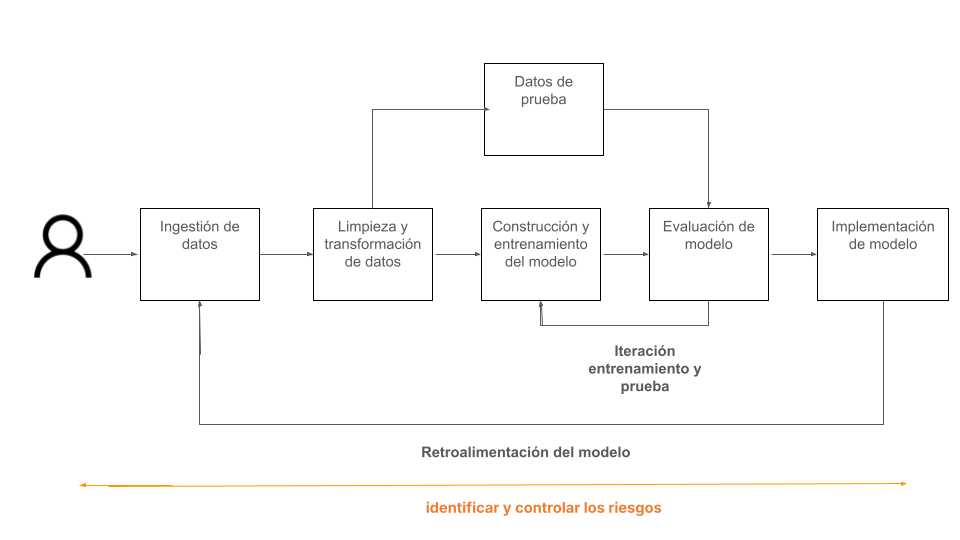

### 🥇 Aprendizaje supervisado
El modelo aprende de un conjunto de datos que incluye la salida deseada, llamada etiqueta. A este conjunto de datos se los llama **conjunto de datos etiquetados**.

Desde un lenguaje matemático, el objetivo en aprendizaje automático supervisado es encontrar una función $f$ que, al recibir una nueva entrada $x$, dé una salida que sea lo más parecida posible al verdadero $y$.



$$(x_i, y_i) \sim p(x, y) \quad \text{i.i.d.}$$  
$$x_i \in \mathbb{R}^p$$  
$$y_i \in \mathbb{R}$$  
$$f(x_i) \approx y_i$$


En donde:

* $(x_i, y_i) \sim p(x, y) \quad \text{i.i.d.}$ : los datos provienen de una distribución conjunta, de manera independiente e idénticamente distribuida (i.i.d.). Cada muestra de datos o instancia de entrenamiento. Lo podemos ver como par (entrada, salida).

* $x_i \in \mathbb{R}^p$ : cada entrada  $x_i$ es un vector de dimensión $p$. Por ejemplo, si tienes 10 características o variables, $x_i$ es un vector en ℝ¹⁰.

* $y_i \in \mathbb{R}$: cada salida es un valor real. En clasificación, muchas veces $y_i$ en realidad sería una clase discreta como 0, 1, 2; en regresión sí es un valor real continuo.

* $f(x_i) \approx y_i$​: la $f$ intenta aproximar la salida verdadera.




**Queremos un modelo lo suficientemente apropiado para captar ideas complejas.**

$$f(x_i) \approx y_i$$
$$f(x) \approx y$$


####  Clasificación
Una tarea típica de aprendizaje supervisado es la clasificación. Se busca predecir un valor discreto. Se entrena un modelo que a partir de las características (los valores $x$ de nuestra función) predice una etiqueta ($y$), la cual se vincula con la probabilidad de que el caso observado pertenezca a cada una de las clases posibles, prediciendo la etiqueta más probable de ocurrir.

* Ejemplo: *¿Correo Spam? ¿idioma de un sitio web? ¿Tumor maligno? ¿Cambiará de compañía telefónica? ¿Dígito nombrado?*


  









## 🎯 Modelos de Clasificación

Tipos de clasificaciones

* **Binaria**: La variable objetivo ($y$) tiene dos categorías posibles.
  * Ejemplo :  tiene diabetes o no, spam/no spam, si/no, entre otros.

* **Multiclase**:  La variable objetivo ($y$) tiene más de dos categorías posibles.
  * Ejemplo: Tres tipos de especie de pingüinos, Clasificación de películas, Categorías de productos, etc.

### 🥇 Clasificación binaria

Empecemos con un ejemplo de **clasificación binaria**, en el que el modelo debe predecir una **etiqueta que pertenece a una de las dos clases**. En este ejercicio, entrenaremos un clasificador binario para predecir si un **paciente tiene o no diabetes**.




#### Conjunto de datos

Ejecute la siguiente celda para cargar el archivo CSV de los datos de pacientes en dataframe de **Pandas**:

**Contexto**

Este conjunto de datos procede del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales.


**Objetivo del modelo**

Predecir diagnósticamente si un paciente tiene o no diabetes basándose en determinadas mediciones incluidas en el conjunto de datos.

Se impusieron varias restricciones a la selección de estos casos de una base de datos más amplia. En particular, todos los pacientes son mujeres de al menos 21 años y de ascendencia india pima.

**Diccionario de datos**

* PatientID: Identificador de paciente.
* Pregnancies: Número de embarazos.
* PlasmaGlucose: Concentración plasmática de glucosa a las 2 horas en una prueba de tolerancia oral a la glucosa.
* DiastolicBloodPressure: Presión arterial diastólica (mmHg).
* TricepsThickness: Espesor del pliegue cutáneo tricipital (mm).
* SerumInsulin: Insulina sérica a las 2 horas (mu U/ml).
* BMI: Índice de masa corporal (peso en kg/(altura en m)^2).
* DiabetesPedigree: Función de pedigrí de diabetes.
* Age: Edad (años).
* Diabetic:  Variable de clase (0 o 1). 268 de 768 son 1, las demás son 0.

[Informacion del conjunto de datos](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)


In [ ]:
import pandas as pd

url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'diabetes.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

diabetes_df = pd.read_csv(ruta_archivo)

In [ ]:
diabetes_df.shape # Informar sobre la cantidad de filas y columnas

In [ ]:
diabetes_df.info() # Informar resumen

* Se identifican **10 características o variables cuantitativas** sobre diagnósticos de pacientes de diabetes y **15000 observaciones de pacientes**.

* La variable objetivo, salida esperada del modelo, ($y$) es *Diabetic*. Esta clase tiene dos etiquetas:
  * 1 -> Clase positiva en la prueba de la diabetes.
  * 0 -> Clase negativa en la prueba de la diabetes
* Las características a utilizar, entradas posibles del modelo ($x$) son: [*Pregnancies, PlasmaGlucose, DiastolicBloodPressure,      TricepsThickness, SerumInsulin, BMI, DiabetesPedigree, Age* ]

#### Análisis exploratorio inicial de datos

In [ ]:
diabetes_df.describe().T # Estadística descriptiva

In [ ]:
# Características y etiquetas separadas

caracteristica = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure','TricepsThickness','SerumInsulin','BMI','DiabetesPedigree','Age']
etiqueta = 'Diabetic'

X = diabetes_df[caracteristica].values # Entrada
Y = diabetes_df[etiqueta].values # Salida

# Imprimir algunos ejemplos
for n in range(0,4):
    print("\n Paciente", str(n+1), "\n  Características:",list(X[n]), "\n  etiqueta:", Y[n])

In [ ]:
diabetes_df["Diabetic"].value_counts("%")*100

Podemos apreciar un pequeño desbalance en los datos, es muy importante percatarse de esto previo al entrenamiento y ajuste de un modelo de clasificación.

[Estrategías para tratar clases desbalanceadas](https://machinelearningmastery.com/tactics-to-combat-imbalanced-classes-in-your-machine-learning-dataset/)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a countplot to visualize the distribution of 'Outcome' values
sns.countplot(x='Diabetic', data=diabetes_df)

# Agregar una etiqueta al eje x
plt.xlabel('0 -> No diabetes   1 -> Diabetes')

# Agregar una etiqueta al eje y
plt.ylabel('Frecuencia')

# Establecer el título de la trama
plt.title('Distribución de la variable objetivo')

plt.show()

In [ ]:
sns.pairplot(diabetes_df[['Diabetic', 'Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness']], hue = etiqueta, diag_kind="hist")


In [ ]:
sns.pairplot(diabetes_df[['Diabetic', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age']],hue=etiqueta,diag_kind="hist" )



Algunas de las características permiten observar una diferencia notable en la distribución para los valores de la etiqueta. En particular, *Pregnancies* (Embarazo) y *Age* (Edad) muestran distribuciones notablemente diferentes para los pacientes diabéticos, a diferencia de los no diabéticos. Estas características parecen ser las de mayor relevancia a la hora de predecir si un paciente es diabético o no.

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Agrupar los datos por la columna 'Resultado' y calcular la media para cada grupo
diabetes_df.groupby('Diabetic').describe()

No se identifica valores faltantes.

In [ ]:
diabetes_df.isnull().sum()

En esta primera iteración, vamos a considerar los datos sin tranformaciones y se utilizarán todas las características de entradas identificadas anteriormente.


#### División de datos

El objetivo es entrenar un clasificador de forma que encuentre una relación estadística (**función**) entre las características y el valor de la etiqueta; pero **¿cómo sabremos si nuestro modelo es bueno? ¿Cómo sabremos si predice correctamente cuando lo utilicemos con datos nuevos con los que no se ha entrenado?**.

Para la selección y evaluación de modelos hay que explorar distintas configuraciones de modelos (algoritmo + hiperparámetros + características) para poder seleccionar el mejor mediante mediciones con alguna métrica; y una vez seleccionada la configuración, estimar la performance que tendrá de la mejor manera posible.

La evaluación de una configuración de modelo requiere separar los datos. Por ejemplos en **datos de entrenamientos, validación y prueba**. Los datos se deben separar al azar, para evitar cualquier orden o estructura subyacente en los datos.

En Python, el paquete **scikit-learn** contiene un gran número de funciones que podemos aprovechar a la hora de construir un modelo de aprendizaje automático, incluida la función **train_test_split**, que garantiza una división estadísticamente aleatoria de los datos de entrenamiento y de validación. Utilizaremos esta función para dividir los datos en un **70%** para el entrenamiento y un **30%** para la validación.

[sklearn.model_selection.train_test_split()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
# Recordar que hicimos:
# X = diabetes_df[caracteristica].values
# Y = diabetes_df [etiqueta].values

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en un 70%-30% en el conjunto de entrenamiento y el conjunto de validación
X_train, X_test, y_train, y_test = train_test_split(diabetes_df[caracteristica], diabetes_df[etiqueta], test_size=0.30, random_state=0)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=0) #Otra forma

print ('Instancias de entrenamiento: %d\nInstancias de validación: %d' % (X_train.shape[0], X_test.shape[0]))

In [ ]:
import numpy as np
unique_elements, counts_elements = np.unique(y_train, return_counts=True)
print("Entrenamiento:")
print(np.asarray((unique_elements, counts_elements)))
print(y_train.shape)

unique_elements, counts_elements = np.unique(y_test, return_counts=True)
print("Validación:")
print(np.asarray((unique_elements, counts_elements)))
print(y_test.shape)

#### Entrenar y evaluar un modelo de clasificación binaria

Bien, ya estamos listos para entrenar nuestro modelo, a partir de las **características** de entrenamiento (**X_train**) buscaremos ajustar una "funcion" que establezca la relación con las etiquetas del conjuntos de datos de entrenamiento (**y_train**). Existen múltiples algoritmos que podemos implementar para crear el modelo.





### 🥇 K-Vecinos Más Próximos (KNN k-Nearest Neighbors)


Encontrar una función $f$ que, al recibir una nueva entrada $x$, dé una salida que sea lo más parecida posible al verdadero $y$

$$
f(x) = y_i,\quad i = \arg\min_j \|x_j - x\|
$$


- **$x$**: es un nuevo punto (ejemplo, instancia) que queremos clasificar o predecir.
- **$x_j$**: son los puntos de entrenamiento, es decir, ejemplos ya conocidos con sus etiquetas.
- **$\|x_j - x\|$**: es la **distancia** entre el nuevo punto $ x$ y el punto de entrenamiento $x_j$.  
  Por lo general, se usa la distancia Euclídea.
- **$arg\min_j \|x_j - x\|$**: significa "el índice $j$ que **minimiza** la distancia".  
  Es decir, buscamos el punto más cercano a $x$.
- **$y_i$**: es la **etiqueta** (o valor objetivo) del punto más cercano.
- **$f(x) = y_i$**: la predicción para $x $ es igual a la etiqueta de su vecino más cercano.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Crear modelo - configuración
knn_clf= KNeighborsClassifier(n_neighbors=5)
knn_clf

In [ ]:
# Entrenamiento
knn_clf.fit(X_train, y_train)

In [ ]:
# Predicción
y_pred_knn = knn_clf.predict(X_test)
y_pred_knn

In [ ]:
# Evaluación
print("Modelo  K-Vecinos Más Próximos")
# Medición
print("Métrica de evaluación (Accuracy) promedio:", accuracy_score(y_test, y_pred_knn))


Lo más obvio que podemos hacer es comprobar la **accuracy** de las predicciones: en términos sencillos, **¿qué proporción de las etiquetas predijo correctamente el modelo?**. Por lo pronto utilizaremos esta métrica para presentar los tipos de clasificadores. Más adelante presentaremos otras.

Los clasificadores de Scikit-Learn siempre tienen un método `decision_function()` o un método `predict_proba()`, o a veces ambos. `predict_proba()` devuelve las probabilidades de clase para cada instancia.

In [ ]:
y_scores_knn = knn_clf.predict_proba(X_test)
pd.DataFrame({'proba_0':y_scores_knn[:,0],'proba_1':y_scores_knn[:,1],'categoria':y_pred_knn}).head(15)

📝 Ejercicio


Dado a que knn trabaja con distancias, es necesario escalar las variables numéricas. Aquí los datos nuevos.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score

from sklearn.preprocessing import StandardScaler
import time
# X_train, X_test, y_train, y_test = train_test_split(diabetes_df[caracteristica], diabetes_df[etiqueta], test_size=0.30, random_state=0)

# Escalamos los datos con StandardScaler
scaler_std = StandardScaler() # Objeto transformador
X_train_std = scaler_std.fit_transform(X_train) # Aprende sobre los datos de entrenamiento y luego los transforma
X_test_std = scaler_std.transform(X_test) # transforma los datos de prueba
print("Datos de test escalado por Z-score")
print(X_test_std)

1- Entrenar un modelo de knn usando los datos transformados. Medir el rendimiento con la métrica accuracy. ¿Cuál es el valor del accuracy?

In [ ]:
# Crear modelo - configuración
knn_clf= KNeighborsClassifier(n_neighbors=5)
# Entrenamiento
knn_clf.fit(X_train_std, y_train)
# Predicción
y_pred_knn = knn_clf.predict(X_test_std)
# Evaluación
print("Modelo  K-Vecinos Más Próximos")
# Medición
print("Métrica de evaluación (Accuracy) promedio:", accuracy_score(y_test, y_pred_knn))

2. Reentrenar el modelo KNN usando los datos escalados y distintos valores de k: 1, 3, 5, 7.
Para cada modelo, registrar:

* Accuracy y F1-scoree
* Tiempo de predicción (usando %%time o time.time())

¿Qué relación observás entre el valor de k y la performance? ¿Hay un punto en el que el modelo comienza a “suavizarse demasiado”?

In [ ]:
# Repetimos el entrenamiento con distintos valores de k.
# Observamos cómo cambia el rendimiento y el tiempo de cómputo.
# Probar distintos valores de k
for k in [1, 3, 5, 7, 15]:
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_train_std, y_train)
    start = time.time()
    y_pred = knn_clf.predict(X_test_std)
    end = time.time()
    print(f"K={k}, Accuracy={accuracy_score(y_test, y_pred):.2f}, F1={f1_score(y_test, y_pred):.2f}, Tiempo={end - start:.4f} s")

    # Para k>3 , en general el valor de Accuracy y F1 crece, tal el modelo comienza a suavizarse. Para k = 5 se observa un punto intermedio entre los mejores valores del Accuracy y F1.


### 🥇 Regresión logística


Modelo lineal

Ecuación lineal:
$$
y = ax + b
$$

En donde $y$ es la variable dependiente o de salida y $x$ la variable independiente o de entrada, $a$ es **la pendiente** y $b$ la **ordenada al origen**.



In [ ]:
a=1
b=10
X = [0,3,6,9,12]
Y = []
for x in X:
    Y.append(a*x+b)
print(Y)
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter([6,7,4,9,12],[10, 13, 16, 19,20])
ax.plot(X,Y, color='red')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Recta y= ax+b')

La fórmula general para hacer una predicción en un modelo lineal es:

$$
\hat{y} = \sum_i w_i x_i + b
$$

¿Qué significa cada símbolo?

- $\hat{y} $: predicción del modelo (se lee "y sombrero").
- $x_i$: i-ésima característica (variable de entrada).
- $w_i$: peso aprendido para la característica $x_i$.
- $b$: término independiente o sesgo (**bias**).
- $\sum_i w_i x_i$: suma ponderada de las características, es decir, qué tanto influye cada variable en la predicción.

¿Dónde se usa esta fórmula?

- En **regresión lineal**: la salida es un valor numérico (como precio, temperatura, etc.).
- En **regresión logística**: esta combinación lineal se transforma con una función sigmoide para obtener una probabilidad.
- En **perceptrones y redes neuronales**: se usa como paso previo a una función de activación.

Aquí te lo presentamos de manera simplista, pero hay más detrás.

En la regresión logística aplicamos la función sigmoide

$$
g(z) = \frac{1}{1 + e^{-z}}
$$

La salida del modelo pasa por la sigmoide (Tomamos la salida como la probabilidad para la clase postiva)
:

$$
P(y = 1 \mid x) = g(w^T x + b)
$$


La probabilidad se convierte en una predicción usando un umbral:

$$
\hat{y} =
\begin{cases}
1 & \text{si } g(w^T x + b) \geq 0.5 \\
0 & \text{si } g(w^T x + b) < 0.5
\end{cases}
$$



Donde:

- $y_i \in \{0, 1\} $ es la **etiqueta verdadera**.
- $\hat{y}_i \in (0, 1)$ es la **probabilidad predicha** por el modelo para la clase positiva.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Crear modelo - Configuración
regLog_clf = LogisticRegression(max_iter=1000)
regLog_clf

In [ ]:
# Entrenamiento
regLog_clf.fit(X_train, y_train)
regLog_clf

In [ ]:
# Predicción
y_pred_regLog = regLog_clf.predict(X_test)
y_pred_regLog

In [ ]:
# Evaluación
print("Modelo Regresión logística")
# Medición
print("Métrica de evaluación (Accuracy) promedio:", accuracy_score(y_test, y_pred_regLog))


La regresión logística  emplea un **valor umbral (threshold value) de 0,5** para decidir si la etiqueta predicha es un 1 ($P(y) > 0,5$) o un 0 ($P(y) \leq 0,5$), es decir que a partir del valor de umbral podemos traducir de la probabilidad predicha a la etiqueta predicha.


In [ ]:
y_scores_regLog = regLog_clf.predict_proba(X_test)
pd.DataFrame({'proba_0':y_scores_regLog[:,0],'proba_1':y_scores_regLog[:,1],'categoria':y_pred_regLog}).head(15)

📝 Ejercicio

1. El siguiente ejemplo nos permite trabajar en la interpretación de coeficientes del modelo (coef_). Cada coeficiente tiene asociado una variable del entrenamieto. Responder:
* ¿Qué interpretación se puede hacer? Por ejemplo: ¿el aumento del índice de masa corporal (BMI) incrementa o disminuye la probabilidad de tener diabetes?¿qué sucede con el número de embarazos (Pregnancies)?



In [ ]:
import numpy as np
import pandas as pd



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Crear modelo - Configuración
regLog_clf = LogisticRegression(max_iter=1000)
# Entrenar
regLog_clf.fit(X_train, y_train)
y_pred_regLog = regLog_clf.predict(X_test)
# Evaluar
print("Métrica de evaluación (Accuracy) promedio:", accuracy_score(y_test, y_pred_regLog))
# Analzar la influencia de cada variable en la probabilidad de tener diabetes.
coef = pd.Series(regLog_clf.coef_[0], index=X_train.columns)
print("Coeficientes del modelo:")
print(coef.sort_values())


2. Por defecto, la regresión logística clasifica como 1 si la probabilidad es mayor a 0.5. Probá con otros umbrales: 0.3, 0.7. En el siguiente ejemplo, un ejemplo de cambios de umbrales. Responder:

* Analizando solo los valores de las métricas seleccionadas. ¿Qué umbral elegirías?


In [ ]:
from sklearn.metrics import accuracy_score,f1_score

# Cambiamos el umbral de decisión para observar cómo se afectan precisión y recall.
for threshold in [0.3, 0.5, 0.7]:
    y_proba = regLog_clf.predict_proba(X_test)[:,1]
    y_pred = (y_proba >= threshold).astype(int)
    print(f"\nUmbral={threshold}")
    print("Accuracy: ",accuracy_score(y_test, y_pred))
    print("F1: ", f1_score(y_test, y_pred))

### 🥇 Árboles de decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Crear modelo - Configuración
arbolDe_clf = DecisionTreeClassifier(random_state=42)
arbolDe_clf


Existen diferentes Hiperparámetros a configurar. En este ejemplo, consideramos todos los valores por defecto e indicamos la semilla de aleatoridad para hacer replicable el modelo. Por ejemplo max_depth es un hiperparámetros que indica la profundidad máxima del árbol. Si es None, por defecto, los nodos se expanden hasta que todas las hojas sean puras o hasta que todas las hojas contengan menos de min_samples_split muestras (por defecto 2).


In [ ]:
arbolDe_clf.get_params()

In [ ]:
# Entrenamiento
arbolDe_clf.fit(X_train, y_train)
arbolDe_clf

In [ ]:
# Predicción
y_pred_arbolDec = arbolDe_clf.predict(X_test)
y_pred_arbolDec

In [ ]:
# Evaluación
print("Modelo árbol de decisión")
# Medición
print("Métrica de evaluación (Accuracy) promedio:", accuracy_score(y_test, y_pred_arbolDec))


In [ ]:
y_scores_arbolDec = arbolDe_clf.predict_proba(X_test)
pd.DataFrame({'proba_0':y_scores_arbolDec[:,0],'proba_1':y_scores_arbolDec[:,1],'categoria':y_pred_arbolDec}).head(15)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configurar tamaño de la figura
plt.figure(figsize=(20,10))

# Visualizar el árbol
plot_tree(arbolDe_clf, feature_names=caracteristica, class_names=["No Diabetes","Diabetes"], filled=True)

# Mostrar la figura
plt.show()


In [ ]:
!pip install graphviz
# Puede ser necesario instalar el paquete

In [ ]:
from sklearn.tree import export_graphviz
import graphviz


dot_data = export_graphviz(arbolDe_clf, out_file=None,
                           feature_names=caracteristica,
                           class_names=["No Diabetes","Diabetes"],
                           filled=True, rounded=True,
                           special_characters=True)


graph = graphviz.Source(dot_data)
graph

📝 Ejercicio

El siguiente ejemplo evalua el rendimiento para distintas profundidades del árbol para el conjunto de datos. En base a resultados, responder

*  ¿Cuál parece ser el punto donde comienza el overfitting?

Analizar cuándo comienza el overfitting a partir de una gráfica de accuracy en entrenamiento y test implica observar cómo cambian esas métricas al aumentar la complejidad del modelo. ¿El accuracy en entrenamiento sigue subiendo? ¿El accuracy en test empieza a bajar o estancarse?.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

train_scores = []
test_scores = []
depths = [2, 4, 6, 10, None]

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Graficar
depth_labels = [str(d) if d is not None else "None" for d in depths]
plt.figure(figsize=(8,5))
plt.plot(depth_labels, train_scores, label="Entrenamiento", marker='o')
plt.plot(depth_labels, test_scores, label="Test", marker='o')
plt.xlabel("Profundidad del árbol (max_depth)")
plt.ylabel("Accuracy")
plt.title("Profundidad del árbol vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()



## 🎯 Métricas para evaluar modelos de clasificación

### 🥇 Matriz de confusión o contingencia de las clasificaciones



In [ ]:
from sklearn.metrics import confusion_matrix

# Matriz de confusion KNN
cm_arbolDec = confusion_matrix(y_test, y_pred_arbolDec)
cm_arbolDec

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

sns.heatmap(cm_arbolDec, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title("Matriz de confusión de árbol de decisión")
ax.set_xlabel("Valores Predichos")
ax.set_ylabel("Valores Actual o Real")

plt.tight_layout()
plt.show()

In [ ]:
TN, FP = 2763, 223
FN, TP = 244, 1270

Para calcular la matriz de confusión, primero necesitas un conjunto de predicciones para compararlas con los objetivos reales.
En `confusion_matrix` cada fila representa una clase real, mientras que cada columna representa una clase predicha.


### 🥇 Métricas

##### Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

print('Accuracy promedio: ', accuracy_score(y_test, y_pred_arbolDec))

In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

accuracy

La accuracy se devuelve como un valor decimal: un valor de 1.0 significaría que el modelo acertó el 100% de las predicciones, mientras que una accuracy de 0.0 es inútil.


* El modelo acierta en el 90% de los casos.
* Cuidado: En problemas con clases desbalanceadas, esta métrica puede ser engañosa (por ejemplo, si predice siempre “no tiene diabetes”, también tendría alta accuracy).

Afortunadamente, hay otras métricas que revelan algo más sobre el rendimiento de nuestro modelo.

##### Precision

In [ ]:
from sklearn.metrics import precision_score

print('En general Precision: ', precision_score(y_test, y_pred_arbolDec, average=None))
print('Precision promedio: ', precision_score(y_test, y_pred_arbolDec))

In [ ]:
precision = TP / (TP + FP)
precision

* El 85% de los pacientes que el modelo predijo como diabéticos realmente lo son.
* Está métrica es importante cuando los falsos positivos son costosos.

#### Recall

In [ ]:
from sklearn.metrics import recall_score, f1_score
print('En general Recall: ', recall_score(y_test, y_pred_arbolDec, average=None))
print('Recall promedio: ', recall_score(y_test, y_pred_arbolDec))


In [ ]:
recall = TP / (TP + FN)
recall

* El modelo detecta correctamente el 84% de los casos de diabetes.
* Muy importante en salud: un falso negativo (persona con diabetes no detectada) puede tener consecuencias graves.

##### F-Score (F1)

In [ ]:
from sklearn.metrics import f1_score
print('En general F-Score (F1): ', f1_score(y_test, y_pred_arbolDec, average=None))
print('F-Score (F1) promedio: ', f1_score(y_test, y_pred_arbolDec))


In [ ]:
f1 = 2 * (precision * recall) / (precision + recall)
f1

* El modelo mantiene un buen balance entre no alarmar en falso y no dejar casos sin detectar.

Scikit-Learn incluye la capacidad de crear un informe de clasificación que proporciona más información que la precisión bruta por sí sola.

In [ ]:
from sklearn. metrics import classification_report

print(classification_report(y_test, y_pred_arbolDec))

In [ ]:
from sklearn. metrics import classification_report

print(classification_report(y_test, y_pred_arbolDec,target_names=["No diabetes","Diabetes"]))

### 🥇 Curva de ROC

Una forma habitual de evaluar un clasificador es examinar la tasa de verdaderos positivos (que es otro nombre para la recall) y la tasa de falsos positivos para un rango de posibles umbrales. Estas tasas se trazan entonces frente a todos los umbrales (threshold) posibles y se forma un gráfico ampliamente conocido como gráfico ROC, como éste:

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores_arbolDec[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva de ROC')
plt.show()

El área bajo la curva (AUC) es un valor entre 0 y 1 que cuantifica el rendimiento global del modelo. Cuanto más se acerque a 1 este valor, mejor será el modelo. Una vez más, scikit-Learn incluye una función para calcular esta métrica.

In [ ]:
y_scores_arbolDec[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test,y_scores_arbolDec[:,1])
print('AUC: ' + str(auc))

Consideraciones específicas del dominio (salud)

* Falsos Negativos (FN): Casos reales de diabetes que el modelo no detecta. Muy graves. El paciente no recibe tratamiento.
* Falsos Positivos (FP): Casos que el modelo detecta como diabetes sin que lo sean. Menos graves, pero pueden generar "estrés" o exámenes innecesarios.

Un valor de AUC = 0.882 significa que el modelo tiene una alta capacidad de distinguir entre clases. En este caso, entre pacientes que tienen y no tienen diabetes.


📝 Ejercicio

Suponé que el sistema será usado por personal de atención primaria en centros de salud para detectar posibles casos no diagnosticados.

El siguiente ejemplo evalua el rendimiento de un modelo para distintas profundidades del árbol. En base a los resultados, responder:



In [ ]:
train_scores = []
test_scores = []
depths = [2, 4, 6, 10, None]

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    y_pred_arbolDec = model.predict(X_test)
    print("Profundidad del árbol (max_depth):", d)
    print(classification_report(y_test, y_pred_arbolDec,target_names=["No diabetes","Diabetes"]))
    train_acc = f1_score(y_train, model.predict(X_train))
    test_acc = f1_score(y_test, model.predict(X_test))
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Graficar
depth_labels = [str(d) if d is not None else "None" for d in depths]
plt.figure(figsize=(8,5))
plt.plot(depth_labels, train_scores, label="Entrenamiento", marker='o')
plt.plot(depth_labels, test_scores, label="Test", marker='o')
plt.xlabel("Profundidad del árbol (max_depth)")
plt.ylabel("F1")
plt.title("Profundidad del árbol vs F1 score")
plt.legend()
plt.grid(True)
plt.show()


*  En el centro de Salud, es importante reducir los costos por casos de pacientes mal diagnosticados, principalmente en  "diabete cuando no lo son": ¿Qué metricas explorarías?¿Con cuál configuración de modelo te quedarías en base a max_depth?


## 🎯 Concepto de sobreajuste. Train-test, cross validation.

**¿Cómo estimamos la performance de una configuración dada?**

En este ejemplo vamos a cambiar de problema de clasificación. Estás trabajando con clasificación multiclase en el área Biología. El conjunto de datos Iris es clásico y muy sencillo. Para más detalle ['Conjunto de datos IRIS'](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html).

In [ ]:
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Conjunto de Datos
X, y = datasets.load_iris(return_X_y=True)
X

In [ ]:
datasets.load_iris().feature_names # informar sobre las características


In [ ]:
y

In [ ]:
datasets.load_iris().target_names # Clases - variable objetivo


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3) # Tamaño del dataset de test: 20%

In [ ]:
clf = DecisionTreeClassifier(random_state=2)
clf = clf.fit(X_train, y_train)

In [ ]:
# Calcular las predicciones del modelo
y_pred = clf.predict(X_test)

# Evaluar el modelo de clasificación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Cantidad de casos predichos correctamente:", accuracy_score(y_test, y_pred, normalize=False))

In [ ]:
# Matriz de confusion KNN
cm_arbolDec = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
sns.heatmap(cm_arbolDec, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title("Matriz de confusión de árbol de decisión")
ax.set_xlabel("Valores Predichos")
ax.set_ylabel("Valores Actual o Real")

plt.tight_layout()
plt.show()

### Cross-validation

#### k fold

Proporciona índices de entrenamiento/prueba para dividir los datos en conjuntos de entrenamiento/prueba. Divide el conjunto de datos en k pliegues consecutivos (sin reorganización por defecto).

Cada pliegue se utiliza una vez como validación, mientras que los k-1 pliegues restantes forman el conjunto de entrenamiento.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

clf = DecisionTreeClassifier(random_state=2)

k_folds = KFold(n_splits=5) # divide en 5 pliegues

scores = cross_val_score(clf, X, y, cv=k_folds)

print("Accuracies del Cross Validation:", scores)
print("Accuracy promedio:", scores.mean())
print("Cantidad de folds del CV:", len(scores))

*cross_val_score*, evalúa una puntuación por validación cruzada. En un problema de clasificación multiclase, el scoring por defecto es el 'accuracy'. Para más información de [cross_val_score](https://qu4nt.github.io/sklearn-doc-es/modules/generated/sklearn.model_selection.cross_val_score.html)

Notar que el promedio de las accuracies del Cross-Validation es distinto que la accuracy calculada antes con un solo fold.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

clf = DecisionTreeClassifier(random_state=2)

k_folds = KFold(n_splits=5) # divide en 5 pliegues

scores = cross_val_score(clf, X, y, cv=k_folds, scoring='f1_macro')

print("f1_macro del Cross Validation:", scores)
print("f1_macro:", scores.mean())
print("Cantidad de folds del CV:", len(scores))

Para ver más sobre las métricas [scoring](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter)

## Búsqueda de hiperparámetros

Dado un método como el Árbol de Decisión, son múltiples las variantes de hiperparámetros que se pueden considerar para entrenar al modelo. Para explorarlas y seleccionar la más conveniente, usaremos los métodos de *Grid Search* y *Ramndomized Search*.

Scikit-learn ofrece los métodos respectivos `GridSearchCV` y `RandomizedSearchCV` que analizan distintas configuraciones usando Cross-validation y se quedan con la mejor en función a alguna métrica (para clasificación será por defecto la *accuracy* pero se puede usar otra).

### Grid Search


Cuenta con los siguientes parámetros clave:
* **Estimator**: tipo de modelo a buscar (*DecissionTree*, *kNN*, etc.).
* **Param_grid**: diccionario especificando los parámetros a explorar.
* **Scoring**: métrica usada para evaluar el rendimiento del modelo.
* **CV**: la estrategia a usar para Cross-validation (si se usa un número entero, es la cantidad de Folds).

Continuemos con el ejemplo del dataset Iris:

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.metrics import accuracy_score

arbol_de_decision = DecisionTreeClassifier(random_state=5)

# Definimos los parámetros a explorar (la grilla de parámetros)
param_grid = {
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4, 5, 6, 7, 8],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(10)
scoring = 'accuracy'

In [ ]:
# Definimos el GridSearchCV
grid_search = GridSearchCV(estimator=arbol_de_decision,
                           param_grid=param_grid,
                           cv=cv,
                           scoring=scoring,
                           n_jobs=-1 # indica la cantidad de subprocesos a paralelizar. -1 indica lanzar todos los que se pueda
                           )

# Buscamos los hiperparámetros
grid_search.fit(X_train, y_train)

print("Mejor configuración de parámetros:", grid_search.best_params_)
print("Mejor puntaje:", grid_search.best_score_)

### Randomized Search

Los parámetros clave son los mismos que los del Grid Search pero se le agrega `n_iter`: entero que indica cuántas configuraciones se explorarán. Lógicamente, mientras más se exploren, mayor la probabilidad de obtener un mejor resultado pero más costoso en tiempo es.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV


arbol_de_decision = DecisionTreeClassifier(random_state=5)

param_grid = {
    'max_features': ['sqrt', 'log2'],
    'max_depth': range(2, 20),
    'criterion': ['gini', 'entropy']
}

clf = RandomizedSearchCV(estimator=arbol_de_decision,
                         param_distributions=param_grid,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=3)
search = clf.fit(X, y)

print("Mejor configuración de parámetros:", search.best_params_)
print("Mejor puntaje:", search.best_score_)